In [1]:
import numpy as np
import pandas as pd
import os
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.gridspec import GridSpec
import argparse
import re
import seaborn as sns

In [2]:
#%% set up path
path = r'/gpfs/work4/0/FWC2/Spatial_dependence/Disease_outbreak/global'
df_all = pd.read_csv(os.path.join(path,'data','public_emdat_custom_request_admin1.csv'))

#%% shapefile fid, ISO, Country
shpfilename = os.path.join(path,'data/shapefile/ne_10m_admin_0_countries.shp')
shp = gpd.read_file(shpfilename,engine="pyogrio")
shp = shp.rename(columns={'SOV_A3':'ISO'})
shp = shp[['ISO','geometry']]

In [3]:
# identify the first significant lag for each country and hazard type
hazard_type = 'Natural Hazard'
disease_type = 'waterborne'
# res = pd.read_csv(os.path.join(path,'output','global/all',f'res_aggregated_rates_global_{hazard_type}_{disease_type}.csv'))
# df_sig_lag = pd.DataFrame(index=res.index, columns=['FID', 'ISO', 'First_sig_T'])
# df_sig_lag['FID'] = res['FID']
# df_sig_lag['ISO'] = res['ISO']

# # detect sig columns and sort by lag number
# sig_cols =res.columns[np.arange(3,41,3)]

# # boolean DataFrame where True means sig==1
# sig_bool = (res[sig_cols] == 1)

# # find column name of first True; set NaN where none True
# first_col = sig_bool.idxmax(axis=1)
# first_col = first_col.where(sig_bool.any(axis=1), other=np.nan)
# df_sig_lag['First_sig_T'] = first_col.str.extract(r"(\d+)").astype(float)+1
# df_sig_lag.loc[df_sig_lag['First_sig_T']==13, 'First_sig_T'] = 12
# df_sig_lag.to_csv(os.path.join(path,'output','sig_time_lag',f'first_sig_lag_global_{disease_type}_{hazard_type}.csv'), index=False)
df_sig_lag = pd.read_csv(os.path.join(path,'output','sig_time_lag',f'first_sig_lag_global_{disease_type}_{hazard_type}.csv'))
df = shp.merge(df_sig_lag, how='left',on='ISO')
## original code to get the significant time lag
# hazard_type_all = ['Flood', 'Drought', 'Storm', 'Landslide','Volcanic activity', 'Wildfire', 'Extreme temperature', 'Earthquake']
# disease_type = 'waterborne'

# for i, hazard_type in enumerate(hazard_type_all):
#     res = pd.read_csv(os.path.join(path,'output','global',f'res_aggregated_rates_global_{hazard_type}_{disease_type}.csv'))

#     if i == 0:
#         df_sig_lag = pd.DataFrame(index=res.index, columns=['FID', 'ISO'] + hazard_type_all)
#         df_sig_lag['FID'] = res['FID']
#         df_sig_lag['ISO'] = res['ISO']
    
#     # detect sig columns and sort by lag number
#     sig_cols =res.columns[np.arange(3,41,3)]

#     # boolean DataFrame where True means sig==1
#     sig_bool = (res[sig_cols] == 1)

#     # find column name of first True; set NaN where none True
#     first_col = sig_bool.idxmax(axis=1)
#     first_col = first_col.where(sig_bool.any(axis=1), other=np.nan)
#     df_sig_lag[hazard_type] = first_col.str.extract(r"(\d+)").astype(float)+1
# df_sig_lag.to_csv(os.path.join(path,'output','sig_time_lag',f'first_sig_lag_global_{disease_type}.csv'), index=False)

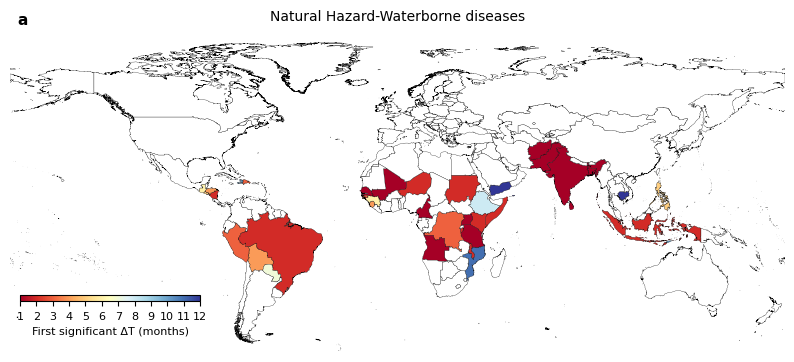

In [ ]:
# plotting the first significant lag month for each hazard-disease combination
# Create figure with 12 subplots (1 row x 3 columns)
fig = plt.figure(figsize=(10, 6))
crg = ccrs.PlateCarree()
plt.rcParams.update({'font.size': 9})
plt.rcParams['hatch.linewidth'] = 1
cmap = mpl.colormaps.get_cmap("RdYlBu").copy()
# cmap = mpl.colormaps.get_cmap("Reds_r").copy()
norm = mpl.colors.Normalize(vmin=1, vmax=12)
# bins = np.arange(0, 1.1, 0.1)
# norm = mpl.colors.BoundaryNorm(bins, cmap.N)
panel = ['a','b']

# global hotspot of first significant lag for all naturan hazards - epidemic
ax = fig.add_subplot(projection=crg)
df.plot(
        ax=ax, column='First_sig_T', cmap=cmap, vmin=1, vmax=12,
        linewidth=0.2, edgecolor='k',
        missing_kwds={"color": "white", "edgecolor": "k", "linewidth": 0.2}
    )

# Add panel label in the upper-left corner (axes fraction coordinates)
ax.text(0.01, 1.05, panel[0], transform=ax.transAxes, fontsize=11, fontweight='bold', va='top', ha='left')
ax.set_extent([-180, 180, -60, 90], crs=crg)
ax.set_title(f'Natural hazards - Waterborne diseases', fontsize=10)
ax.set_axis_off()

# Add colorbar
# Add colorbar at a specific location
cax = fig.add_axes([0.135, 0.31, 0.18, 0.01])
#              [left, bottom, width, height]

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation='horizontal'
)

cbar.set_label(
    'First significant ΔT (months)',
    size=8
)

cbar.set_ticks(np.linspace(1, 12, 12))
cbar.ax.tick_params(labelsize=8)
# Save the figure
outputdir = os.path.join(path, 'figures')
plt.savefig(os.path.join(outputdir, f'first_sig_lag_{disease_type}_{hazard_type}_RdYlBu_a.png'),
            dpi=450, bbox_inches='tight')

In [ ]:
disease_type = 'waterborne'
df_sig_lag = pd.read_csv(os.path.join(path,'output','sig_time_lag',f'first_sig_lag_global_{disease_type}.csv'))
hazard_type_all = ['Flood', 'Drought', 'Storm', 'Landslide','Volcanic activity', 'Wildfire', 'Extreme temperature', 'Earthquake']
df_sig_lag = df_sig_lag.loc[
    (df_sig_lag[hazard_type_all].notna()).any(axis=1)
].reset_index(drop=True)
df_sig_lag.drop(columns=['FID'], inplace=True)
df_sig_lag = df_sig_lag.rename(columns={
    'Flood': 'F',
    'Drought': 'D',
    'Storm': 'S',
    'Landslide': 'L',
    'Volcanic activity': 'V',
    'Wildfire': 'W',
    'Extreme temperature': 'ET',
    'Earthquake': 'E'
})
df_sig_lag = df_sig_lag.set_index("ISO")
df_sig_lag[df_sig_lag==13] = 12

In [11]:
df_sig_lag

,F,D,S,L,V,W,ET,E
ISO,,,,,,,,
AFG,1.0,1.0,6.0,5.0,NaN,NaN,3.0,4.0
AGO,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
BDI,NaN,2.0,9.0,NaN,NaN,NaN,NaN,NaN
BGD,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN
BOL,11.0,6.0,NaN,NaN,NaN,4.0,NaN,NaN
BRA,2.0,2.0,12.0,NaN,NaN,NaN,NaN,NaN
CMR,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COD,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COG,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


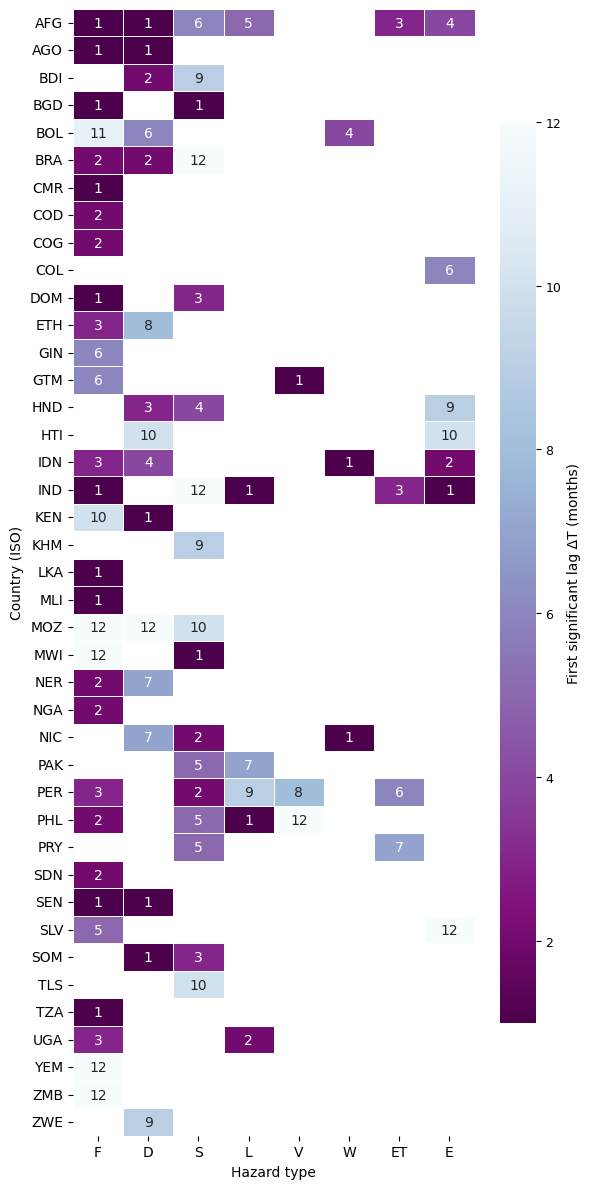

In [25]:
# plotting the first significant lag month for each hazard-disease combination
# Create the heatmap
plt.figure(figsize=(6, 12))

hm = sns.heatmap(
    df_sig_lag,
    cmap="BuPu_r",     # your colormap
    vmin=1,
    vmax=12,
    annot=True,        # show numbers
    fmt=".0f",         # integer formatting
    linewidths=0.5,
    cbar_kws={"label": "First significant lag ΔT (months)","shrink": 0.8, "aspect": 25
    }
)

cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=9)

plt.xlabel("Hazard type")
plt.ylabel("Country (ISO)")
plt.tight_layout()

outputdir = os.path.join(path, 'figures')
plt.savefig(os.path.join(outputdir, f'heatmap_first_sig_lag_{disease_type}_vertical.png'),
            dpi=450, bbox_inches='tight')

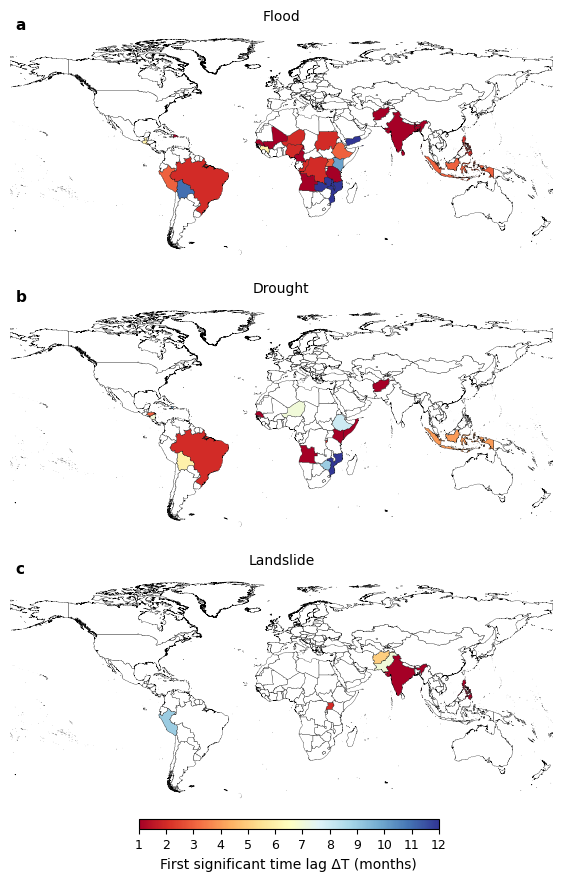

In [27]:
# plotting the first significant lag month for each hazard-disease combination
# Create figure with 12 subplots (1 row x 3 columns)
fig = plt.figure(figsize=(10, 10))
gs = GridSpec(3, 1, figure=fig)
crg = ccrs.PlateCarree()
plt.rcParams.update({'font.size': 9})
plt.rcParams['hatch.linewidth'] = 1
cmap = mpl.colormaps.get_cmap("RdYlBu").copy()
# cmap = mpl.colormaps.get_cmap("Reds_r").copy()
norm = mpl.colors.Normalize(vmin=1, vmax=12)
# bins = np.arange(0, 1.1, 0.1)
# norm = mpl.colors.BoundaryNorm(bins, cmap.N)
panel = ['a','b','c']

for i, hazard_type in enumerate(['Flood', 'Drought', 'Landslide']):
    ax = fig.add_subplot(gs[i, 0], projection=crg)
    df.plot(
            ax=ax, column=hazard_type, cmap=cmap, vmin=1, vmax=12,
            linewidth=0.2, edgecolor='k',
            missing_kwds={"color": "white", "edgecolor": "k", "linewidth": 0.2}
        )

    # mask_pos = ~df[hazard_type].isna()
    # mask_nan = df[hazard_type].isna()

    # if mask_pos.any():
    #     df[mask_pos].plot(
    #         ax=ax, column=hazard_type, cmap=cmap, vmin=1, vmax=12,
    #         linewidth=0.5, edgecolor='k'
    #     )

    # if mask_nan.any():
    #     df[mask_nan].plot(
    #         ax=ax, color="none", edgecolor="k",
    #         linewidth=0.1 
    #     )

    # Add panel label in the upper-left corner (axes fraction coordinates)
    ax.text(0.01, 1.05, panel[i], transform=ax.transAxes, fontsize=11, fontweight='bold', va='top', ha='left')
    ax.set_extent([-180, 180, -60, 90], crs=crg)
    ax.set_title(f'{hazard_type}', fontsize=10)
    ax.set_axis_off()

# Add ONE shared colorbar
cax = fig.add_axes([0.37, 0.08, 0.3, 0.01])
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(
sm, cax=cax, orientation='horizontal'
)
cbar.set_label(f'First significant time lag ΔT (months)', size=10)
cbar.set_ticks(np.linspace(1, 12, 12))

# Save the figure
outputdir = os.path.join(path, 'figures')
plt.savefig(os.path.join(outputdir, f'first_sig_lag_{disease_type}_RdYlBu_a.png'),
            dpi=450, bbox_inches='tight')